<a href="https://colab.research.google.com/github/guravharshvardhan/Deep-Learning/blob/main/Experiment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# ---------------- LOAD DATA ----------------

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# ---------------- MODEL FUNCTION ----------------

def build_model(initializer):
    model = Sequential([
        Dense(128, activation='relu', kernel_initializer=initializer, input_shape=(784,)),
        Dense(64, activation='relu', kernel_initializer=initializer),
        Dense(10, activation='softmax')
    ])
    return model


In [ ]:
# ---------------- INITIALIZER COMPARISON ----------------

initializers = {
    "RandomNormal": tf.keras.initializers.RandomNormal(),
    "Xavier": tf.keras.initializers.GlorotUniform(),
    "HeNormal": tf.keras.initializers.HeNormal()
}

histories = {}

for name, init in initializers.items():
    model = build_model(init)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nTraining with {name} Initialization...")
    history = model.fit(x_train, y_train, epochs=10, batch_size=128, verbose=0)

    histories[name] = history

    # ---- PRINT EPOCH VALUES ----
    print(f"\n{name} Epoch Results:")
    for i in range(10):
        print(f"Epoch {i+1}: Loss={history.history['loss'][i]:.4f}, "
              f"Accuracy={history.history['accuracy'][i]:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with RandomNormal Initialization...

RandomNormal Epoch Results:
Epoch 1: Loss=0.3580, Accuracy=0.9019
Epoch 2: Loss=0.1449, Accuracy=0.9572
Epoch 3: Loss=0.0989, Accuracy=0.9708
Epoch 4: Loss=0.0739, Accuracy=0.9782
Epoch 5: Loss=0.0575, Accuracy=0.9827
Epoch 6: Loss=0.0455, Accuracy=0.9866
Epoch 7: Loss=0.0366, Accuracy=0.9896
Epoch 8: Loss=0.0300, Accuracy=0.9916
Epoch 9: Loss=0.0246, Accuracy=0.9934
Epoch 10: Loss=0.0210, Accuracy=0.9941

Training with Xavier Initialization...

Xavier Epoch Results:
Epoch 1: Loss=0.3396, Accuracy=0.9029
Epoch 2: Loss=0.1362, Accuracy=0.9606
Epoch 3: Loss=0.0938, Accuracy=0.9718
Epoch 4: Loss=0.0714, Accuracy=0.9788
Epoch 5: Loss=0.0564, Accuracy=0.9835
Epoch 6: Loss=0.0452, Accuracy=0.9868
Epoch 7: Loss=0.0362, Accuracy=0.9898
Epoch 8: Loss=0.0288, Accuracy=0.9924
Epoch 9: Loss=0.0237, Accuracy=0.9939
Epoch 10: Loss=0.0205, Accuracy=0.9944

Training with HeNormal Initialization...

HeNormal Epoch Results:
Epoch 1: Loss=0.3246, Accuracy=0.

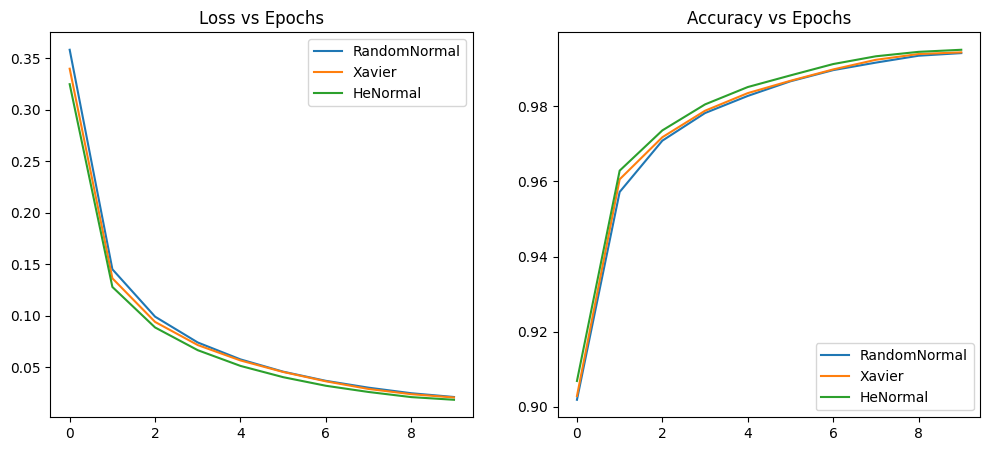

In [ ]:
# ---------------- PLOT INITIALIZER GRAPHS ----------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for name in histories:
    plt.plot(histories[name].history['loss'], label=name)
plt.title("Loss vs Epochs")
plt.legend()

plt.subplot(1,2,2)
for name in histories:
    plt.plot(histories[name].history['accuracy'], label=name)
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()

In [ ]:
# ---------------- OPTIMIZER COMPARISON ----------------
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

opt_histories = {}

for name, opt in optimizers.items():
    model = build_model(tf.keras.initializers.HeNormal())

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nTraining with {name} Optimizer...")
    history = model.fit(x_train, y_train, epochs=10, batch_size=128, verbose=0)

    opt_histories[name] = history

    # ---- PRINT EPOCH VALUES ----
    print(f"\n{name} Epoch Results:")
    for i in range(10):
        print(f"Epoch {i+1}: Loss={history.history['loss'][i]:.4f}, "
              f"Accuracy={history.history['accuracy'][i]:.4f}")



Training with SGD Optimizer...

SGD Epoch Results:
Epoch 1: Loss=1.1366, Accuracy=0.7011
Epoch 2: Loss=0.4610, Accuracy=0.8767
Epoch 3: Loss=0.3645, Accuracy=0.8982
Epoch 4: Loss=0.3219, Accuracy=0.9091
Epoch 5: Loss=0.2948, Accuracy=0.9166
Epoch 6: Loss=0.2747, Accuracy=0.9220
Epoch 7: Loss=0.2584, Accuracy=0.9264
Epoch 8: Loss=0.2447, Accuracy=0.9304
Epoch 9: Loss=0.2329, Accuracy=0.9337
Epoch 10: Loss=0.2225, Accuracy=0.9367

Training with Adam Optimizer...

Adam Epoch Results:
Epoch 1: Loss=0.3071, Accuracy=0.9120
Epoch 2: Loss=0.1288, Accuracy=0.9622
Epoch 3: Loss=0.0903, Accuracy=0.9738
Epoch 4: Loss=0.0674, Accuracy=0.9805
Epoch 5: Loss=0.0517, Accuracy=0.9852
Epoch 6: Loss=0.0408, Accuracy=0.9887
Epoch 7: Loss=0.0320, Accuracy=0.9910
Epoch 8: Loss=0.0256, Accuracy=0.9934
Epoch 9: Loss=0.0213, Accuracy=0.9948
Epoch 10: Loss=0.0192, Accuracy=0.9948


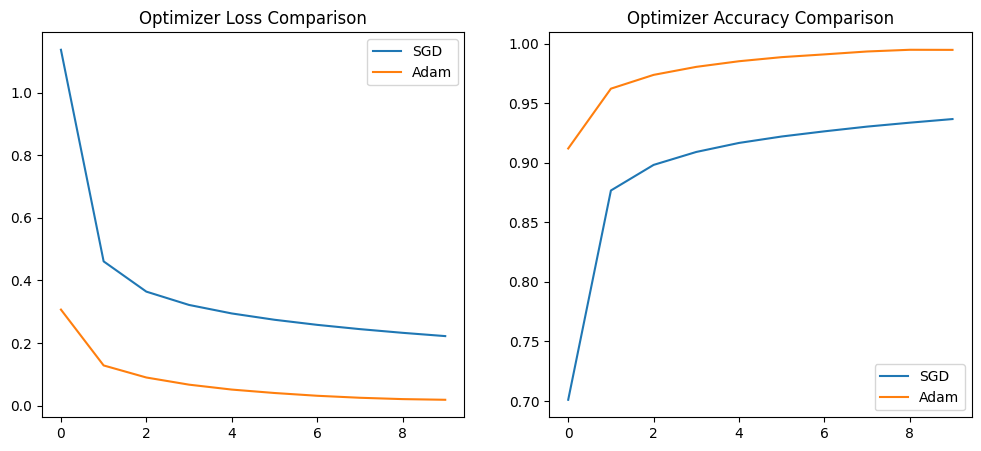

In [ ]:
# ---------------- PLOT OPTIMIZER GRAPHS ----------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for name in opt_histories:
    plt.plot(opt_histories[name].history['loss'], label=name)
plt.title("Optimizer Loss Comparison")
plt.legend()

plt.subplot(1,2,2)
for name in opt_histories:
    plt.plot(opt_histories[name].history['accuracy'], label=name)
plt.title("Optimizer Accuracy Comparison")
plt.legend()

plt.show()


In [ ]:
# ---------------- FINAL ACCURACY ----------------
print("\nFinal Accuracy Comparison:")
for name in opt_histories:
    final_acc = opt_histories[name].history['accuracy'][-1]
    print(f"{name}: {final_acc:.4f}")


Final Accuracy Comparison:
SGD: 0.9367
Adam: 0.9948
